# Data Science Lab Project

In [42]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("C:\\Users\\HP\\Desktop\\università\\DATA SCIENCE\\FIRST YEAR\\DATA SCIENCE LAB\\Progetto old\\Database.csv")

# Dictionary to rename columns with more descriptive names (only exact column names)
column_mapping = {
    'qd1': 'Gender',
    'qd2': 'Geographic_Area', 
    'qd3': 'Municipality_Size',
    'qd6': 'Household_Composition',
    'qd7': 'Age',
    'qd8': 'Professional_Status',
    'qd9': 'Education_Level',
    'qd10': 'Work_Sector',
    'qd11': 'Professional_Role',
    'qd12': 'Citizenship',
    'qd13': 'Income_Bracket',
    'qd14': 'Purchase_Motivation',
    'qd15': 'Online_Purchase_Frequency',
    'qd16': 'Preferred_Purchase_Channels',
    'qd17': 'Devices_Used',
    'qd18': 'Purchase_Influence_Factors',
    'qd19': 'Review_Importance',
    'qd20': 'Encountered_Problems',
    'qd21': 'Experience_Satisfaction',
    'qd22': 'Improvement_Recommendations',
    'qf11': 'difficulty_covering_expenses',
    'qk3': 'Inflation_knowladge',
    'qk1' : 'financial_literacy',
    'qf1': 'Money_responable'
}

# rename exact columns
df = df.rename(columns=column_mapping)



# convert Age to numeric 
if 'Age' in df.columns:
    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# show dataset dimensions
print(f"Dataset Shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\n" + "="*50)
print("FIRST 5 ROWS OF THE DATASET:")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("COLUMN INFORMATION:")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("DESCRIPTIVE STATISTICS (NUMERIC COLUMNS):")
print("="*50)
print(df.describe())

# check for missing values
print("\n" + "="*50)
print("MISSING VALUES PER COLUMN:")
print("="*50)
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Values': missing_values,
    'Percentage': missing_percentage.round(2)
})
print(missing_df[missing_df['Missing_Values'] > 0])

Dataset Shape: (4862, 219)
Number of rows: 4862
Number of columns: 219

FIRST 5 ROWS OF THE DATASET:
  Gender   Age qd7_a Geographic_Area  \
0   Uomo  68.0   NaN    Nord - Ovest   
1   Uomo  36.0   NaN             Sud   
2  Donna  64.0   NaN             Sud   
3  Donna  50.0   NaN             Sud   
4   Uomo  66.0   NaN             Sud   

                                   Municipality_Size qd5_1 qd5_2 qd5_3 qd5_4  \
0  Una città con numero di abitanti compreso tra ...    Sì    No    No    No   
1  Un comune con numero di abitanti da 3.000 a ci...    No    No    Sì    No   
2  Una città con numero di abitanti compreso tra ...    No    Sì    No    No   
3  Una città con numero di abitanti compreso tra ...    No    No    No    No   
4  Una città con numero di abitanti compreso tra ...    No    Sì    No    No   

  qd5_5 qd5_6 qd5_7 qd5_99 qd5_ad qd5_ch            Work_Sector  \
0    No    No    No     No    NaN    NaN             Pensionato   
1    No    No    No     No      5      3  L

In [43]:
# data types count
print(df.dtypes.value_counts())
print(df.shape)
# missing values top 10 columns
missing = df.isnull().sum().sort_values(ascending=False)
print("Top 10 columns with the most missing values:")
print(missing.head(10))


object     217
float64      2
Name: count, dtype: int64
(4862, 219)
Top 10 columns with the most missing values:
qd7_a       4643
qp2_17      4594
qp3_17      4594
qf12_4_2    4332
qf12_1_3    4332
qf12_2_2    4332
qf12_3_1    4332
qf12_3_2    4332
qf12_3_3    4332
qf12_3_7    4332
dtype: int64


In [44]:
print(df.describe(include='all')) 

       Gender          Age  qd7_a Geographic_Area  \
count    4862  4643.000000    219            4862   
unique      2          NaN      3               5   
top     Donna          NaN  50-59    Nord - Ovest   
freq     2446          NaN    166            1317   
mean      NaN    50.307991    NaN             NaN   
std       NaN    16.680679    NaN             NaN   
min       NaN    18.000000    NaN             NaN   
25%       NaN    36.000000    NaN             NaN   
50%       NaN    50.000000    NaN             NaN   
75%       NaN    65.000000    NaN             NaN   
max       NaN    79.000000    NaN             NaN   

                                        Municipality_Size qd5_1 qd5_2 qd5_3  \
count                                                4862  4862  4862  4862   
unique                                                  5     2     2     2   
top     Una città con numero di abitanti compreso tra ...    No    Sì    No   
freq                                           

## EDA 

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

cols_to_plot = {
    "Gender": "Gender",
    "Age": "Age",
    "Geographic_Area": "Geographic Area",
    "Education_Level": "Education Level",
    "Income_Bracket": "Income Bracket"
}

# extract and rename for visualization
# for the visualization we create a new df
df_viz = df[list(cols_to_plot.keys())].rename(columns=cols_to_plot)

# convert age to numeric
df_viz["Age"] = pd.to_numeric(df_viz["Age"], errors="coerce")

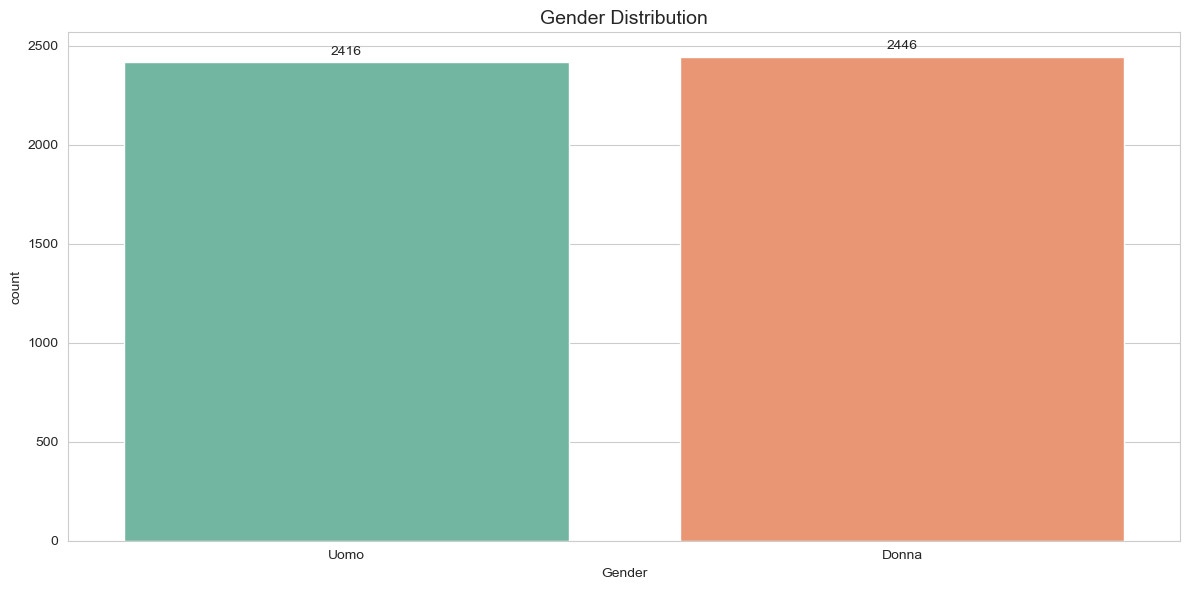

In [46]:
# gender distribution
ax = sns.countplot(data=df_viz, x="Gender", palette="Set2")
plt.title("Gender Distribution", fontsize=14)
plt.xticks(rotation=0)


for p in ax.patches:
    count = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2, 
            p.get_height() + max(df_viz["Gender"].value_counts()) * 0.01,
            count,
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

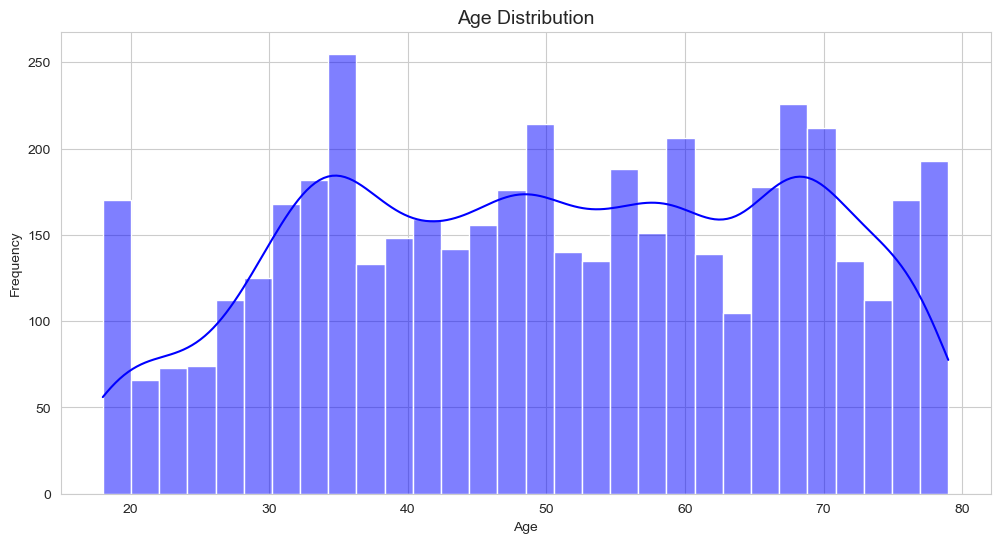

In [47]:
# age distribution
sns.histplot(df_viz["Age"].dropna(), kde=True, bins=30, color="blue")
plt.title("Age Distribution", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

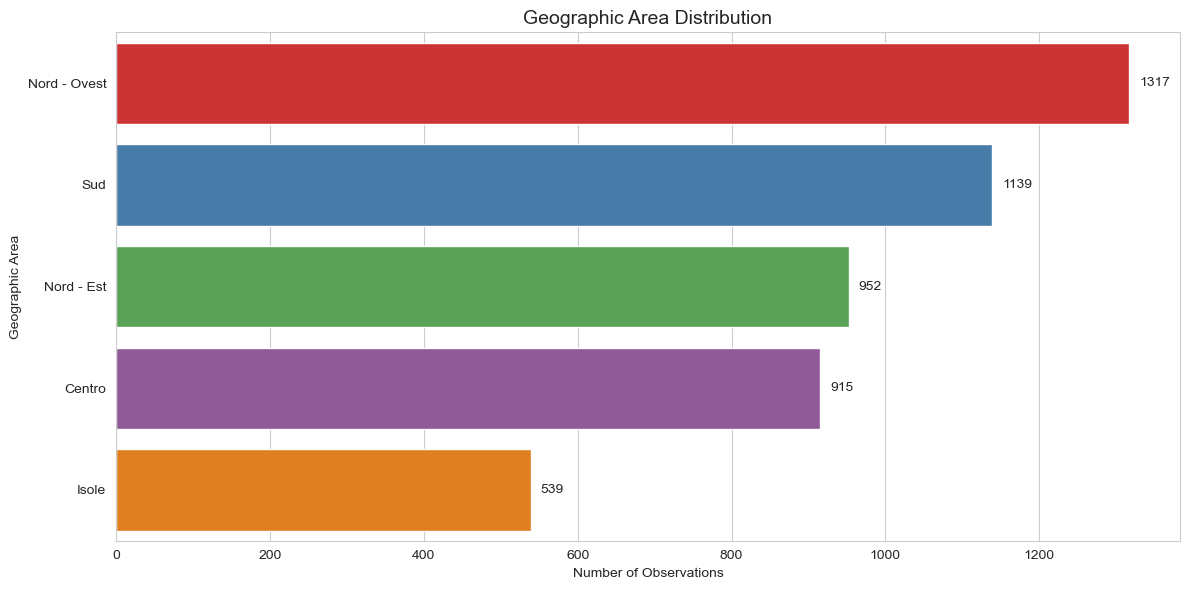

In [48]:
# geographic area distribution
ax = sns.countplot(
    data=df_viz,
    y="Geographic Area",
    order=df_viz["Geographic Area"].value_counts().index,
    palette="Set1"
)
plt.title("Geographic Area Distribution", fontsize=14)
plt.xlabel("Number of Observations")


for p in ax.patches:
    count = int(p.get_width())
    ax.text(
        p.get_width() + max(df_viz["Geographic Area"].value_counts()) * 0.01,  
        p.get_y() + p.get_height() / 2,  
        count,
        va='center',
        ha='left',
        fontsize=10
    )

plt.tight_layout()
plt.show()

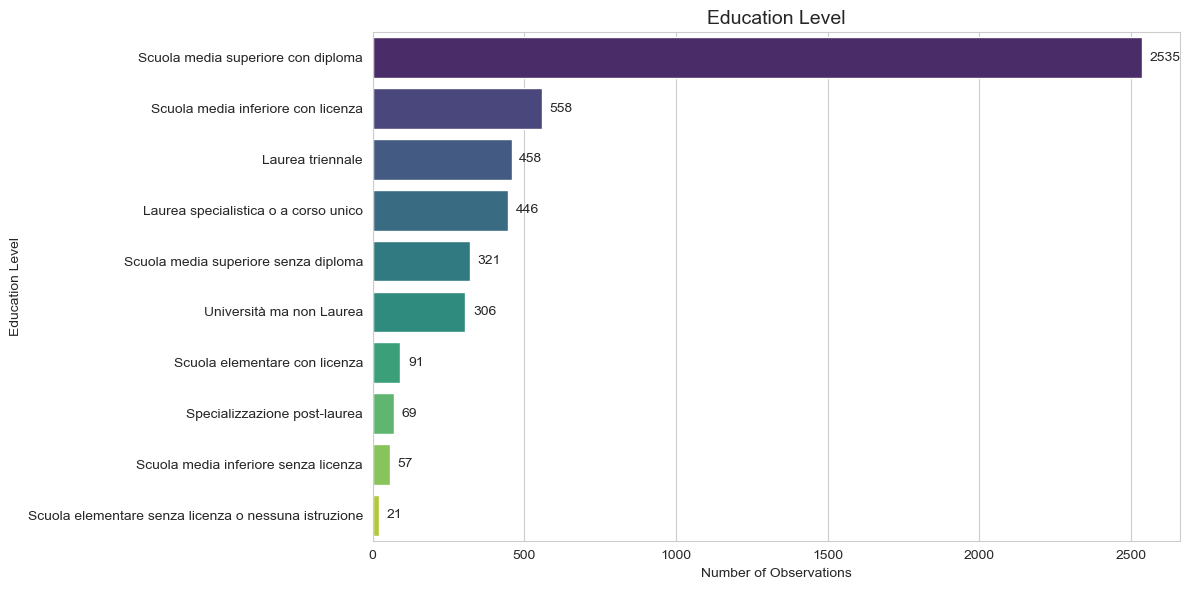

In [49]:
# education level
ax = sns.countplot(
    data=df_viz,
    y="Education Level",
    order=df_viz["Education Level"].value_counts().index,
    palette="viridis"
)

plt.title("Education Level", fontsize=14)
plt.xlabel("Number of Observations")
plt.yticks(fontsize=10)


for p in ax.patches:
    count = int(p.get_width())
    ax.text(p.get_width() + max(df_viz["Education Level"].value_counts()) * 0.01,
            p.get_y() + p.get_height() / 2,
            count,
            va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()


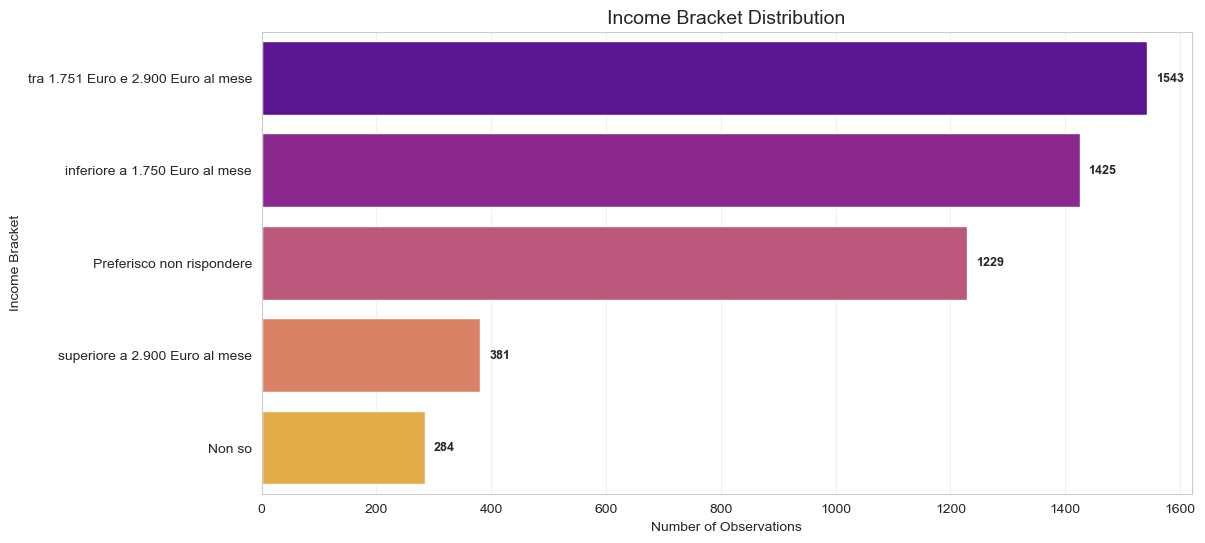

In [50]:
income_counts = df_viz["Income Bracket"].value_counts()


ax = sns.countplot(
    data=df_viz,
    y="Income Bracket",
    order=income_counts.index,
    palette="plasma"
)
plt.title("Income Bracket Distribution", fontsize=14)
plt.xlabel("Number of Observations")
plt.ylabel("Income Bracket")

# Add value labels
for i, category in enumerate(income_counts.index):
    count = income_counts[category]
    ax.text(count + max(income_counts) * 0.01, i, str(count),
            va='center', ha='left', fontsize=9, fontweight='bold')

plt.yticks(fontsize=10)
plt.grid(axis='x', alpha=0.3)
plt.show()

In [51]:
# descriptive analitycs
print("=== SUMMARY STATISTICS ===")
for col in df_viz.columns:
    print(f"\n{col}:") # only numeric variable
    if col == "Age":
        print(f"  - Mean: {df_viz[col].mean():.2f}")
        print(f"  - Median: {df_viz[col].median():.2f}")
        print(f"  - Min-Max: {df_viz[col].min():.0f}-{df_viz[col].max():.0f}")
        print(f"  - Missing values: {df_viz[col].isna().sum()}")
    else:
        if df_viz[col].dropna().empty:
            most_common = 'N/A'
        else:
            most_common = df_viz[col].mode().iloc[0]

        print(f"  - Unique categories: {df_viz[col].nunique()}")
        print(f"  - Most common: {most_common}")
        print(f"  - Missing values: {df_viz[col].isna().sum()}")

=== SUMMARY STATISTICS ===

Gender:
  - Unique categories: 2
  - Most common: Donna
  - Missing values: 0

Age:
  - Mean: 50.31
  - Median: 50.00
  - Min-Max: 18-79
  - Missing values: 219

Geographic Area:
  - Unique categories: 5
  - Most common: Nord - Ovest
  - Missing values: 0

Education Level:
  - Unique categories: 10
  - Most common: Scuola media superiore con diploma
  - Missing values: 0

Income Bracket:
  - Unique categories: 5
  - Most common: tra 1.751 Euro e 2.900 Euro al mese
  - Missing values: 0


## Machine Learning

In [52]:
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
# missing data
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()  
categorical_cols = df.select_dtypes(include=['object']).columns.tolist() 

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")


# handling missing data
# impute missing numeric values with the median


if len(numeric_cols) > 0:
    imputer_numeric = SimpleImputer(strategy='median')
    df[numeric_cols] = imputer_numeric.fit_transform(df[numeric_cols])
    print("Missing numeric values imputed with the median.")

# impute missing categorical values with a constant value
if len(categorical_cols) > 0:
    imputer_categorical = SimpleImputer(strategy='constant', fill_value='Unknown')
    df[categorical_cols] = imputer_categorical.fit_transform(df[categorical_cols])
    print("Missing categorical values imputed with 'Unknown'.")


Numeric columns: 2
Categorical columns: 217
Missing numeric values imputed with the median.
Missing categorical values imputed with 'Unknown'.


In [53]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
print("ENCODING CATEGORICAL VARIABLES")  

print("=" * 50)

# dictionary to store the encoders
label_encoders = {}
encoded_columns = []

# encode only variables with fewer than 50 unique categories
for col in categorical_cols:
    unique_values = df[col].nunique()
    if unique_values < 50:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        encoded_columns.append(col)
        print(f"Encoded {col}: {unique_values} unique categories")

print(f"\nTotal encoded columns: {len(encoded_columns)}")
print(f"Final dataset dimensions: {df.shape}")


ENCODING CATEGORICAL VARIABLES
Encoded Gender: 2 unique categories
Encoded qd7_a: 4 unique categories
Encoded Geographic_Area: 5 unique categories
Encoded Municipality_Size: 5 unique categories
Encoded qd5_1: 2 unique categories
Encoded qd5_2: 2 unique categories
Encoded qd5_3: 2 unique categories
Encoded qd5_4: 2 unique categories
Encoded qd5_5: 2 unique categories
Encoded qd5_6: 2 unique categories
Encoded qd5_7: 2 unique categories
Encoded qd5_99: 2 unique categories
Encoded qd5_ad: 9 unique categories
Encoded qd5_ch: 8 unique categories
Encoded Work_Sector: 10 unique categories
Encoded Purchase_Motivation: 3 unique categories
Encoded qf1_a: 3 unique categories
Encoded Money_responable: 4 unique categories
Encoded qf2_1: 3 unique categories
Encoded qf2_2: 3 unique categories
Encoded qf2_3: 3 unique categories
Encoded qf2_4: 3 unique categories
Encoded qf2_5: 3 unique categories
Encoded qf2_6: 3 unique categories
Encoded qf3_1: 4 unique categories
Encoded qf3_2: 4 unique categories
E

In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import RFE
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')


def calculate_sensitivity_class_0(y_true, y_pred):
    """Calculate sensitivity (recall) for class 0 (bassa financial literacy)"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    # Per classe 0: sensitivity = tn / (tn + fp)
    sensitivity_class_0 = tn / (tn + fp) if (tn + fp) > 0 else 0
    return sensitivity_class_0

def calculate_specificity(y_true, y_pred):
    """Calculate specificity (true negative rate) - ora per classe 1"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return specificity


def preprocess_data(df):

    # target variable cleanup
    df = df[~df['financial_literacy'].isin(['Non so', 'Preferisco non rispondere'])].copy()
    df = df[df['financial_literacy'].isin([1, 2, 3, 4, 5])].copy()
    
    # target binarization 
    df['financial_literacy_level'] = df['financial_literacy'].replace({
        1: 0,  
        2: 0,  
        3: 1,  
        4: 1,  
        5: 1   
    }).astype(int)
    
    # feature engineering
    
    #  age bins
    df['Age_Group'] = pd.cut(df['Age'], 
                            bins=[0, 25, 35, 45, 55, 120], 
                            labels=['Very_Young', 'Young', 'Middle', 'Mature', 'Senior'])
    

    df['Is_Very_Young'] = (df['Age'] < 25).astype(int)
    df['Is_Young_Adult'] = ((df['Age'] >= 25) & (df['Age'] < 35)).astype(int)
    df['Is_Middle_Age'] = ((df['Age'] >= 35) & (df['Age'] < 55)).astype(int)
    df['Is_Senior'] = (df['Age'] >= 55).astype(int)
    
    # financial responsibility
    if 'Money_responable' in df.columns:
        df['Is_Sole_Responsible'] = df['Money_responable'].apply(
            lambda x: 1 if str(x).strip().lower() in ['solo io', 'solo'] else 0)
        df['Is_Shared_Responsible'] = df['Money_responable'].apply(
            lambda x: 1 if 'insieme' in str(x).strip().lower() else 0)
    else:
        df['Is_Sole_Responsible'] = 0
        df['Is_Shared_Responsible'] = 0
    
    # financial difficulties with more granularity
    if 'difficulty_covering_expenses' in df.columns:
        df['High_Financial_Difficulty'] = df['difficulty_covering_expenses'].apply(
            lambda x: 1 if str(x).strip().lower() in ['molto', 'abbastanza'] else 0)
        df['No_Financial_Difficulty'] = df['difficulty_covering_expenses'].apply(
            lambda x: 1 if str(x).strip().lower() in ['per niente', 'poco'] else 0)
    else:
        df['High_Financial_Difficulty'] = 0
        df['No_Financial_Difficulty'] = 0
    
    # income and education with optimized thresholds
    df['Is_High_Income'] = df['Income_Bracket'].apply(lambda x: 1 if x >= 3 else 0)
    df['Is_Low_Income'] = df['Income_Bracket'].apply(lambda x: 1 if x <= 1 else 0)
    df['Is_High_Education'] = df['Education_Level'].apply(lambda x: 1 if x >= 6 else 0)
    df['Is_Low_Education'] = df['Education_Level'].apply(lambda x: 1 if x <= 3 else 0)
    
    # composite features
    df['Education_Income_Ratio'] = df['Education_Level'] / (df['Income_Bracket'] + 1)
    df['Age_Education_Product'] = df['Age'] * df['Education_Level']
    df['Financial_Stress_Score'] = df['High_Financial_Difficulty'] * 2 + df['Is_Low_Income']
    
    # significant interactions
    df['Young_High_Ed'] = df['Is_Young_Adult'] * df['Is_High_Education']
    df['Senior_High_Income'] = df['Is_Senior'] * df['Is_High_Income']
    df['Sole_Resp_High_Ed'] = df['Is_Sole_Responsible'] * df['Is_High_Education']
    
    return df

def select_features(df):

    # base features
    base_features = [
        'Gender', 'Geographic_Area', 'Age', 'Education_Level', 
        'Work_Sector', 'Citizenship', 'Income_Bracket',
        'Purchase_Motivation', 'Money_responable'
    ]
    
    # engineered features
    engineered_features = [
        'Age_Group', 'Is_Very_Young', 'Is_Young_Adult', 'Is_Middle_Age', 'Is_Senior',
        'Is_Sole_Responsible', 'Is_Shared_Responsible',
        'High_Financial_Difficulty', 'No_Financial_Difficulty',
        'Is_High_Income', 'Is_Low_Income', 'Is_High_Education', 'Is_Low_Education',
        'Education_Income_Ratio', 'Age_Education_Product', 'Financial_Stress_Score',
        'Young_High_Ed', 'Senior_High_Income', 'Sole_Resp_High_Ed'
    ]
    
    # conditional features
    conditional_features = ['difficulty_covering_expenses', 'Is_Permanent_Job']
    
    # combine all available features
    all_features = base_features + engineered_features + conditional_features
    available_features = [col for col in all_features if col in df.columns]
    
    return available_features

def optimize_threshold_curve(y_true, y_proba):
    from sklearn.metrics import roc_curve
    
    thresholds_to_test = np.arange(0.05, 0.7, 0.005)
    
    best_score = 0
    best_threshold = 0.3
    
    for threshold in thresholds_to_test:
        y_pred = (y_proba >= threshold).astype(int)
        
        if len(np.unique(y_pred)) > 1:
            acc = accuracy_score(y_true, y_pred)
            

            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            

            tn_rate = tn / (tn + fp) if (tn + fp) > 0 else 0  # Sensitivity classe 0
            tp_rate = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity classe 1
            
            tn_count = tn  
            

            if tn_count >= 120:  
                if acc >= 0.35:
                    combined_score = (tn_rate * 0.7) + (acc * 0.2) + (tp_rate * 0.1)
                else:
                    combined_score = (tn_rate * 0.8) + (acc * 0.1) + (tp_rate * 0.1)
                

                if tn_count >= 150:
                    combined_score *= 1.3
                elif tn_count >= 130:
                    combined_score *= 1.2
                    
            elif tn_count >= 80:  
                combined_score = (tn_rate * 0.6) + (acc * 0.2) + (tp_rate * 0.2)
                if tn_count >= 100:
                    combined_score *= 1.1
            else:
                combined_score = (tn_rate * 0.5) + (acc * 0.3) + (tp_rate * 0.2)
                if tn_count < 50:
                    combined_score *= 0.5
            
            if combined_score > best_score:
                best_score = combined_score
                best_threshold = threshold
    
    return best_threshold


def train_and_evaluate_models(X_train, X_test, y_train, y_test):

    n_samples = len(y_train)
    n_pos = sum(y_train)  
    n_neg = n_samples - n_pos 
    
    base_ratio = n_neg / n_pos
    weight_ratio = base_ratio * 3.0  
    class_weights = {0: 1.0, 1: weight_ratio}

    models = {
        'XGBoost': {
            'model': XGBClassifier(
                use_label_encoder=False,
                eval_metric='logloss',
                random_state=42,
                n_estimators=180,     
                max_depth=4,         
                learning_rate=0.07,  
                subsample=0.85,
                colsample_bytree=0.85,
                reg_alpha=0.03,       
                reg_lambda=0.03,
                min_child_weight=2,   
                gamma=0.02,           
                scale_pos_weight=weight_ratio,
                objective='binary:logistic'
            ),
            'use_scaling': False
        },
        'Random Forest': {
            'model': RandomForestClassifier(
                n_estimators=250,     
                max_depth=9,         
                min_samples_split=7, 
                min_samples_leaf=3,   
                max_features='sqrt',  
                class_weight=class_weights,
                random_state=42,
                bootstrap=True,
                oob_score=True,
                max_samples=0.85     
            ),
            'use_scaling': False
        },
        'Gradient Boosting': {
            'model': GradientBoostingClassifier(
                n_estimators=150,   
                learning_rate=0.08,   
                max_depth=4,
                subsample=0.85,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features='sqrt',
                random_state=42
            ),
            'use_scaling': False
        },
        'Logistic Regression': {
            'model': LogisticRegression(
                max_iter=3000,
                class_weight=class_weights,
                random_state=42,
                C=1.0,            
                penalty='l2',
                solver='lbfgs'
            ),
            'use_scaling': True
        },
        'Ensemble Voting': {
            'model': None,
            'use_scaling': False
        }
    }
    

    from sklearn.feature_selection import SelectKBest, f_classif, RFE
    from sklearn.calibration import CalibratedClassifierCV
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    selector_anova = SelectKBest(score_func=f_classif, k=min(25, X_train.shape[1]))  
    X_train_anova = selector_anova.fit_transform(X_train, y_train)
    X_test_anova = selector_anova.transform(X_test)
    
  
    rf_selector = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rfe = RFE(estimator=rf_selector, n_features_to_select=min(20, X_train_anova.shape[1]), step=1)  
    X_train_selected = rfe.fit_transform(X_train_anova, y_train)
    X_test_selected = rfe.transform(X_test_anova)
    
    X_train_scaled_selected = scaler.fit_transform(X_train_selected)
    X_test_scaled_selected = scaler.transform(X_test_selected)
    

    n_class_0 = (y_train == 0).sum()
    n_class_1 = (y_train == 1).sum()
    

    target_class_0 = int(n_class_1 * 0.9) 
    
    # SMOTE 
    smote = SMOTE(
        random_state=42, 
        k_neighbors=3,  
        sampling_strategy={0: target_class_0}
    )
    

    target_class_1_after = int(target_class_0 * 1.05)  
    under_sampler = RandomUnderSampler(
        random_state=42, 
        sampling_strategy={1: target_class_1_after}
    )
    

    X_train_smoted, y_train_smoted = smote.fit_resample(X_train_selected, y_train)
    X_train_balanced, y_train_balanced = under_sampler.fit_resample(X_train_smoted, y_train_smoted)
    X_train_balanced_scaled = scaler.fit_transform(X_train_balanced)
    
    print(f"Resampling results:")
    print(f"Original: Class 0: {n_class_0}, Class 1: {n_class_1}")
    print(f"After SMOTE: Class 0: {(y_train_smoted == 0).sum()}, Class 1: {(y_train_smoted == 1).sum()}")
    print(f"After Undersampling: Class 0: {(y_train_balanced == 0).sum()}, Class 1: {(y_train_balanced == 1).sum()}")
    
    model_results = []
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    

    ensemble_predictions = []
    ensemble_probabilities = []
    
    for name, config in models.items():
        if name == 'Ensemble Voting':
            if len(ensemble_probabilities) >= 2:
                ensemble_proba = np.mean(ensemble_probabilities, axis=0)
                optimal_threshold = optimize_threshold_curve(y_test, ensemble_proba)
                y_pred = (ensemble_proba >= optimal_threshold).astype(int)
                
                acc_test = accuracy_score(y_test, y_pred)
                specificity = calculate_specificity(y_test, y_pred)
                sensitivity_class_0 = calculate_sensitivity_class_0(y_test, y_pred)
                report = classification_report(y_test, y_pred, labels=[0, 1], 
                                             target_names=['Low_FL', 'High_FL'], output_dict=True)
                confusion = confusion_matrix(y_test, y_pred, labels=[0, 1])
                
                model_results.append({
                    "Model": name,
                    "Test Accuracy": acc_test,
                    "CV Accuracy Mean": 0.0,
                    "CV Accuracy Std": 0.0,
                    "CV F1 Mean": 0.0,
                    "Low_FL Precision": report["Low_FL"]["precision"],
                    "Low_FL Recall": report["Low_FL"]["recall"],
                    "Low_FL F1": report["Low_FL"]["f1-score"],
                    "High_FL Precision": report["High_FL"]["precision"],
                    "High_FL Recall": report["High_FL"]["recall"],
                    "Sensitivity_Class_0": sensitivity_class_0,
                    "Specificity": specificity,
                    "Optimal Threshold": optimal_threshold,
                    "Accuracy*Sensitivity": acc_test * sensitivity_class_0,
                    "Confusion Matrix": confusion.tolist()
                })
            continue
        
        model = config['model']
        use_scaling = config['use_scaling']
        

        if use_scaling:
            X_train_final = X_train_balanced_scaled
            X_test_final = X_test_scaled_selected
        else:
            X_train_final = X_train_balanced
            X_test_final = X_test_selected
        
        if use_scaling:
            X_train_final = X_train_balanced_scaled
            X_test_final = X_test_scaled_selected
        else:
            X_train_final = X_train_balanced
            X_test_final = X_test_selected
        
        model.fit(X_train_final, y_train_balanced)
        
        if hasattr(model, "predict_proba"):
            y_pred_proba = model.predict_proba(X_test_final)[:, 1]
            optimal_threshold = optimize_threshold_curve(y_test, y_pred_proba)
            y_pred = (y_pred_proba >= optimal_threshold).astype(int)
            
            ensemble_probabilities.append(y_pred_proba)
        else:
            y_pred = model.predict(X_test_final)
            optimal_threshold = 0.5
        
        scores_acc = cross_val_score(model, X_train_final, y_train_balanced, 
                                   cv=cv, scoring='accuracy', n_jobs=-1)
        scores_f1 = cross_val_score(model, X_train_final, y_train_balanced, 
                                  cv=cv, scoring='f1', n_jobs=-1)

        acc_test = accuracy_score(y_test, y_pred)
        specificity = calculate_specificity(y_test, y_pred)
        sensitivity_class_0 = calculate_sensitivity_class_0(y_test, y_pred)
        report = classification_report(y_test, y_pred, labels=[0, 1], 
                                     target_names=['Low_FL', 'High_FL'], output_dict=True)
        confusion = confusion_matrix(y_test, y_pred, labels=[0, 1])
        
        model_results.append({
            "Model": name,
            "Test Accuracy": acc_test,
            "CV Accuracy Mean": scores_acc.mean(),
            "CV Accuracy Std": scores_acc.std(),
            "CV F1 Mean": scores_f1.mean(),
            "Low_FL Precision": report["Low_FL"]["precision"],
            "Low_FL Recall": report["Low_FL"]["recall"],
            "Low_FL F1": report["Low_FL"]["f1-score"],
            "High_FL Precision": report["High_FL"]["precision"],
            "High_FL Recall": report["High_FL"]["recall"],
            "Sensitivity_Class_0": sensitivity_class_0,
            "Specificity": specificity,
            "Optimal Threshold": optimal_threshold,
            "Accuracy*Sensitivity": acc_test * sensitivity_class_0,
            "Confusion Matrix": confusion.tolist()
        })
    
    feature_info = {
        'original': X_train.shape[1],
        'anova': X_train_anova.shape[1],
        'final': X_train_selected.shape[1],
        'indices': rfe.support_.nonzero()[0].tolist()
    }
    
    return model_results, feature_info


def main(df):

    print("=== PREPROCESSING AND FEATURE ENGINEERING ===")
    

    df = preprocess_data(df)
    

    feature_columns = select_features(df)
    
    print(f"Features used: {len(feature_columns)}")
    print(f"Chosen variables:\n{feature_columns}")
    print(f"Target distribution: {df['financial_literacy_level'].value_counts().to_dict()}")
    

    X = df[feature_columns]
    y = df['financial_literacy_level']
    

    X_encoded = pd.get_dummies(X, drop_first=True)
    
 
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.2, stratify=y, random_state=42
    )
    
    print(f"Training set dimensions: {X_train.shape}")
    print(f"Test set dimensions: {X_test.shape}")
    
    print("\n=== MODEL TRAINING AND EVALUATION ===")
    
  
    model_results, feature_info = train_and_evaluate_models(X_train, X_test, y_train, y_test)
    
    print(f"\n=== FEATURE SELECTION RESULTS ===")
    print(f"Original features: {feature_info['original']}")
    print(f"After ANOVA selection: {feature_info['anova']}")
    print(f"After RFE selection: {feature_info['final']}")
    print(f"Selected feature indices: {feature_info['indices']}")

    results_df = pd.DataFrame(model_results)
    
    def custom_score(row):
        acc = row['Test Accuracy']
        sens_0 = row['Sensitivity_Class_0']  
        spec_1 = row['Specificity']
        

        tn = row['Confusion Matrix'][0][0]  
        

        if tn >= 120:  
            if tn >= 150:
                return sens_0 * 0.8 + acc * 0.15 + spec_1 * 0.05
            else:
                return sens_0 * 0.7 + acc * 0.2 + spec_1 * 0.1
        elif tn >= 80:
            return sens_0 * 0.6 + acc * 0.25 + spec_1 * 0.15
        else:
  
            return sens_0 * 0.4 + acc * 0.3 + spec_1 * 0.3 * 0.5  #
    
    results_df['Custom_Score'] = results_df.apply(custom_score, axis=1)
    results_df = results_df.sort_values(by='Custom_Score', ascending=False)
    
    print("\n=== FINAL RESULTS ===")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    print(results_df)
    
    return results_df


results = main(df)

=== PREPROCESSING AND FEATURE ENGINEERING ===
Features used: 29
Chosen variables:
['Gender', 'Geographic_Area', 'Age', 'Education_Level', 'Work_Sector', 'Citizenship', 'Income_Bracket', 'Purchase_Motivation', 'Money_responable', 'Age_Group', 'Is_Very_Young', 'Is_Young_Adult', 'Is_Middle_Age', 'Is_Senior', 'Is_Sole_Responsible', 'Is_Shared_Responsible', 'High_Financial_Difficulty', 'No_Financial_Difficulty', 'Is_High_Income', 'Is_Low_Income', 'Is_High_Education', 'Is_Low_Education', 'Education_Income_Ratio', 'Age_Education_Product', 'Financial_Stress_Score', 'Young_High_Ed', 'Senior_High_Income', 'Sole_Resp_High_Ed', 'difficulty_covering_expenses']
Target distribution: {1: 3505, 0: 1048}
Training set dimensions: (3642, 32)
Test set dimensions: (911, 32)

=== MODEL TRAINING AND EVALUATION ===
Resampling results:
Original: Class 0: 838, Class 1: 2804
After SMOTE: Class 0: 2523, Class 1: 2804
After Undersampling: Class 0: 2523, Class 1: 2649

=== FEATURE SELECTION RESULTS ===
Original feat